# Neural Networks Intro

- **Activations ($a, \overrightarrow a$)**: Outputs of one model that then serve as the inputs for other models.
- All of the nodes between the input nodes and the output node are refered to as the "hidden" layer.
- The inputs are refered to as the input layer.
- There can be more than one hidden layer.

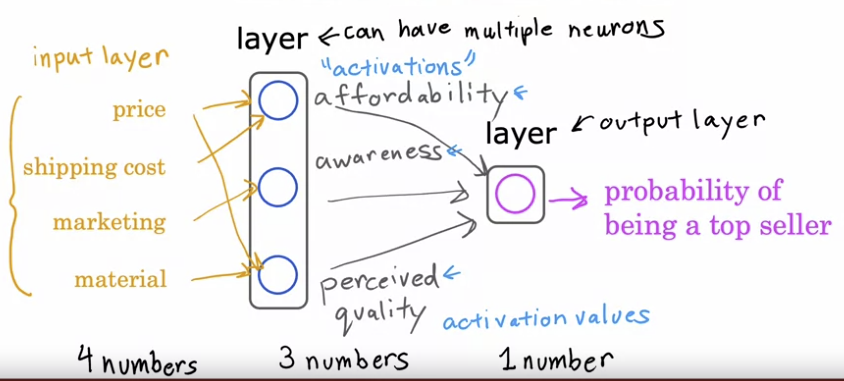

## Layers

- $ \overrightarrow a ^ {[i]} $ referes to the output or activation of layer $i$.
- $\overrightarrow a ^{[3]} = [ a^{[3]}_1, a^{[3]}_2, a^{[3]}_3 ]$ referes to the output vector of layer 3.
    - The subscripts $_i$ indicates the neuron number.
- **Forward Propagation:** When operations are perfromed left to right.
- $ \overrightarrow W _ {2} ^ {[3]} $ would refer to the wieght vector of the second node of the third layer.
- $ \overrightarrow W _ {neuron} ^ {[layer]} $

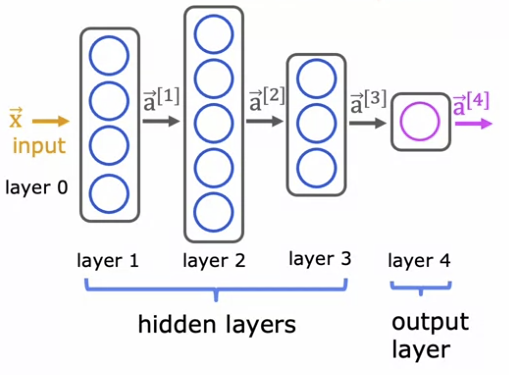

<br><br>

# Neural Networks Intro Lab

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.activations import sigmoid

from lib.lab_utils_common import dlc
from lib.lab_neurons_utils import plt_prob_1d, sigmoidnp, plt_linear, plt_logistic
plt.style.use('./lib/deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

## Neuron without activation - Regression / Linear Model

### Data set

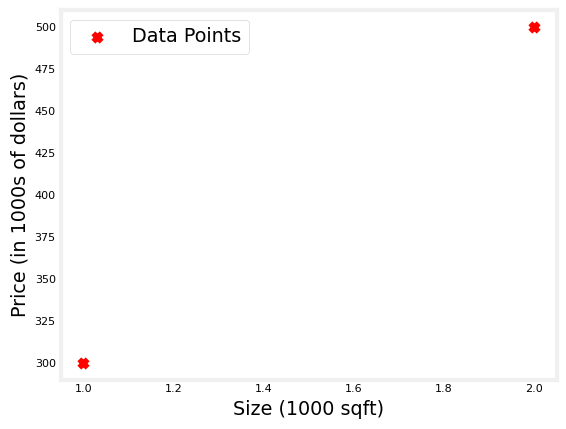

In [16]:
X_train = np.array([[1.0], [2.0]], dtype=np.float32)           #(size in 1000 square feet)
Y_train = np.array([[300.0], [500.0]], dtype=np.float32)       #(price in 1000s of dollars)

fig, ax = plt.subplots(1,1)
ax.scatter(X_train, Y_train, marker='x', c='r', label="Data Points")
ax.legend( fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')
plt.show()

In [17]:
# Instatiate

linear_layer = tf.keras.layers.Dense(units=1, activation = 'linear', )
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

tf.Tensor([[1.19]], shape=(1, 1), dtype=float32)


In [18]:
# Print the weights

w, b= linear_layer.get_weights()
print(f"w = {w}, b={b}")

w = [[1.19]], b=[0.]


In [22]:
# The weights were initialized to random values. Set them manually.

set_w = np.array([[200]])
set_b = np.array([100])

# set_weights takes a list of numpy arrays
linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [23]:
# Compare equation(1) to the layer output.

a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)
alin = np.dot(set_w,X_train[0].reshape(1,1)) + set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


- They produced the same values.

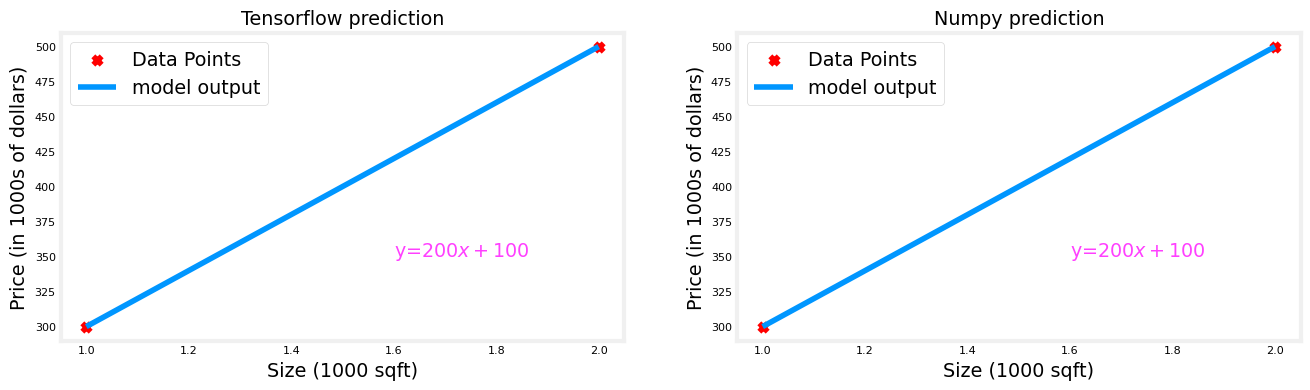

In [27]:
#  Use the linear layer to make predictions

prediction_tf = linear_layer(X_train)
prediction_np = np.dot( X_train, set_w) + set_b

plt_linear(X_train, Y_train, prediction_tf, prediction_np)

## Neuron with Sigmoid activation

In [28]:
# Data set

X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)  # 2-D Matrix
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)  # 2-D Matrix

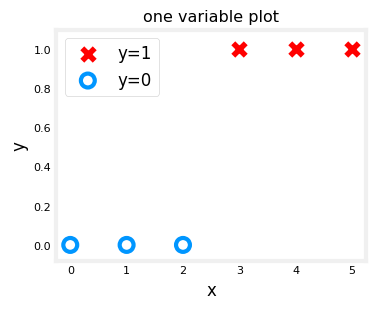

In [29]:
pos = Y_train == 1
neg = Y_train == 0

fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(X_train[pos], Y_train[pos], marker='x', s=80, c = 'red', label="y=1")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, label="y=0", facecolors='none', 
              edgecolors=dlc["dlblue"],lw=3)

ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_title('one variable plot')
ax.legend(fontsize=12)
plt.show()

### Create Logistic Neuron

The [Sequential](https://keras.io/guides/sequential_model/) model is a convenient means of constructing these models.

A logistic neuron, also known as a perceptron with a sigmoid activation, is the fundamental building block of a neural network that takes multiple inputs, calculates their weighted sum (plus bias) to get a "logit," and then passes it through the sigmoid function (1 / (1 + e^-z)) to produce a smooth, non-linear output between 0 and 1, often representing a probability, making it ideal for binary classification tasks. 

In [31]:
model = Sequential(
    [
        tf.keras.layers.Dense(1, input_dim=1,  activation = 'sigmoid', name='L1')
    ]
)

# This prints the layers and number of parameters in the model.
model.summary()

/home/jose-miralles/notes/AI-Notes/machine_learning_specialization_coursera/2_advanced_learning_algorithms/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
logistic_layer = model.get_layer('L1') # Get "L1" from the table above.
w,b = logistic_layer.get_weights()
print(w,b)
print(w.shape,b.shape)

[[-0.06]] [0.]
(1, 1) (1,)


In [36]:
# Manually set the weight and bias

set_w = np.array([[2]])
set_b = np.array([-4.5])
# set_weights takes a list of numpy arrays
logistic_layer.set_weights([set_w, set_b])

# These two should print the same.
print(logistic_layer.get_weights())
print(model.get_layer("L1").get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]
[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


In [38]:
# Compare TF prediction and np prediction.

a1 = model.predict(X_train[0].reshape(1,1))
print(a1)
alog = sigmoidnp(np.dot(set_w,X_train[0].reshape(1,1)) + set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[0.01]]
[[0.01]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

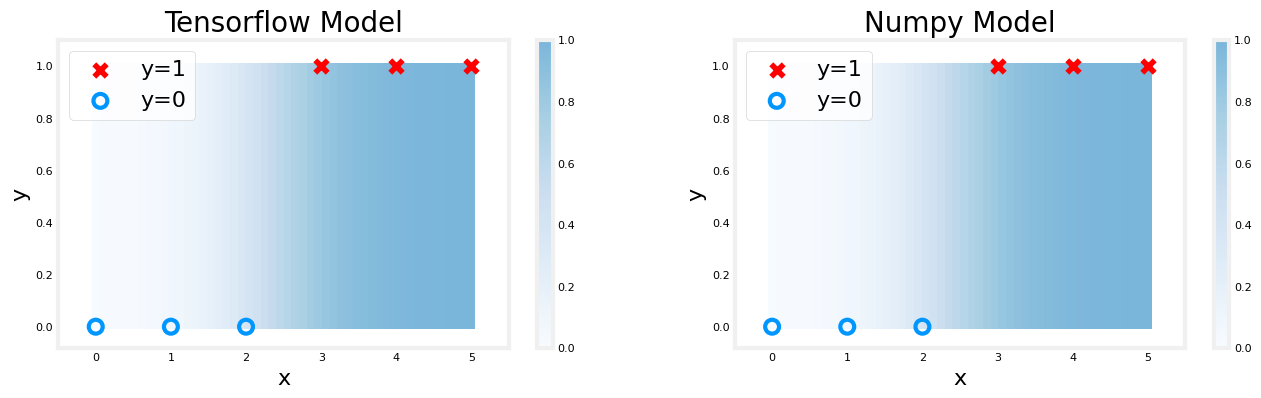

In [40]:
plt_logistic(X_train, Y_train, model, set_w, set_b, pos, neg)